In [1]:
import numpy as np
from utils import *

### Read Subject and Data Preprocessing

In [60]:
b3d_path = "/home/darren/Desktop/grf_estimation/data/AddBiomechanicsDataset./train/With_Arm/Han2023_Formatted_With_Arm/s005_split2/s005_split2.b3d"
trial_num = 0

subject = nimble.biomechanics.SubjectOnDisk(b3d_path)
cop, grf, marker_clouds, subject_mass = load_data_b3d(b3d_path, trial_num=trial_num)
marker_clouds = lowpass_filter(marker_clouds, cutoff_freq=5, fs=100)

#markers_for_centroid = np.array([0,1,2,3,4,5,6,7,8]) # Jeonghan Yoga markers
#markers_for_centroid = np.array([1, 3, 31, 11, 16, 17, 26, 27, 29, 39, 44, 45, 54])  # Fregly2012 torso markers
#markers_for_centroid = np.array([2, 6, 18, 32, 44, 57, 21, 47])  # Carter2023_formatted_with_arm torso markers?
markers_for_centroid = np.array([0, 1, 4, 16, 17, 30, 31, 34, 35, 46, 47, 60, 61, 62, 63]) # Falisse2017_formatted_with_arm torso markers
com = np.nanmean(marker_clouds[:, markers_for_centroid, :], axis=1)

subject_name = f"carter {trial_num}"


frames = subject.readFrames(
    trial=trial_num,
    startFrame=0,
    numFramesToRead=subject.getTrialLength(trial_num),
    includeProcessingPasses=True,  # This is the correct parameter if you need processing passes
)

# frames[10].markerObservations is assumed to be a list of pairs (tuples or lists)
print([(i, pair[0]) for i, pair in enumerate(frames[10].markerObservations)])

[(0, 'head_front'), (1, 'head_l'), (2, 'head_l_ant'), (3, 'head_l_post'), (4, 'head_r'), (5, 'head_r_ant'), (6, 'head_r_post'), (7, 'head_top'), (8, 'l_ank_lat'), (9, 'l_ank_med'), (10, 'l_bicep'), (11, 'l_elb_lat'), (12, 'l_elb_med'), (13, 'l_farm_ant'), (14, 'l_farm_post'), (15, 'l_foot_heel'), (16, 'l_foot_lat'), (17, 'l_foot_m1'), (18, 'l_foot_m2'), (19, 'l_foot_m5'), (20, 'l_foot_med'), (21, 'l_foot_navi'), (22, 'l_foot_toe'), (23, 'l_hand'), (24, 'l_hip_grtr'), (25, 'l_knee_lat'), (26, 'l_knee_med'), (27, 'l_shank_antdist'), (28, 'l_shank_antprox'), (29, 'l_shank_med'), (30, 'l_shank_postdist'), (31, 'l_shank_postprox'), (32, 'l_sho_ant'), (33, 'l_sho_post'), (34, 'l_thigh_ant'), (35, 'l_thigh_antdist'), (36, 'l_thigh_antprox'), (37, 'l_thigh_med'), (38, 'l_thigh_pos'), (39, 'l_thigh_postdist'), (40, 'l_thigh_postprox'), (41, 'l_thmb'), (42, 'l_tricep'), (43, 'l_wri_lat'), (44, 'l_wri_med'), (45, 'pelvis_l'), (46, 'pelvis_l_asis'), (47, 'pelvis_l_ilcr'), (48, 'pelvis_l_psis'), (4

## Visualize Data
### Vertical Ground Reaction Force

First index above 10% bodyweight (with <=2 plates >5% BW): 0
Last index below 10% bodyweight (with <=2 plates >5% BW): 1999


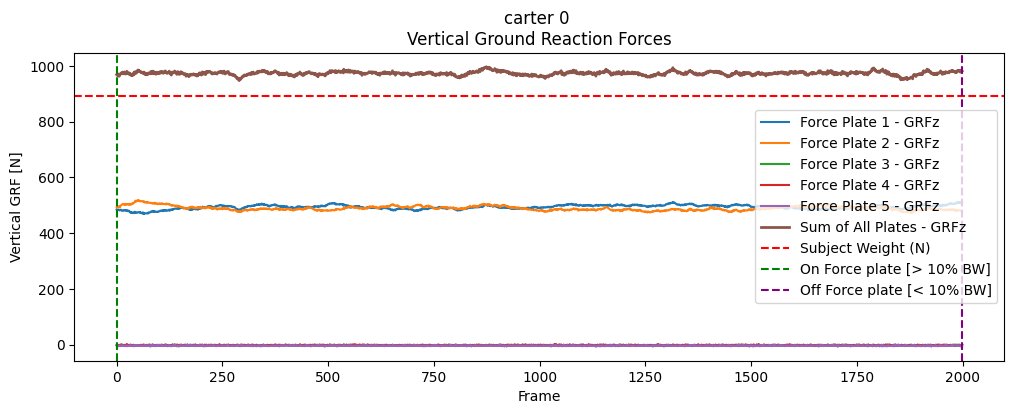

In [61]:
import matplotlib.pyplot as plt

# Compute threshold as 10% of subject bodyweight
threshold = 0.1 * subject_mass * g
minor_plate_threshold = 0.05 * subject_mass * g
sum_grfz = np.sum(grf[:, :, 2], axis=1)

# Find first index where sum_grfz >= threshold and all but one plate < 5% BW
first_above = None
last_below = None
for i in range(len(sum_grfz)):
    # Count number of plates above minor threshold
    above_minor = np.sum(grf[i, :, 2] >= minor_plate_threshold)
    if sum_grfz[i] >= threshold and above_minor <= 2:
        first_above = i
        break

# Find last index where sum_grfz >= threshold and all but one plate < 5% BW (from the end)
for i in range(len(sum_grfz) - 1, -1, -1):
    above_minor = np.sum(grf[i, :, 2] >= minor_plate_threshold)
    if sum_grfz[i] >= threshold and above_minor <= 2:
        last_below = i
        break

print("First index above 10% bodyweight (with <=2 plates >5% BW):", first_above)
print("Last index below 10% bodyweight (with <=2 plates >5% BW):", last_below)



# Plot the vertical GRF (z-component) for both force plates
plt.figure(figsize=(12, 4))
for plate in range(grf.shape[1]):
    plt.plot(grf[:, plate, 2], label=f"Force Plate {plate+1} - GRFz" )
plt.plot(np.sum(grf[:, :, 2], axis=1), label="Sum of All Plates - GRFz", linewidth=2)
plt.axhline(
    subject_mass * 9.81, color="red", linestyle="--", label="Subject Weight (N)"
)
plt.axvline(first_above, color="green", linestyle="--", label="On Force plate [> 10% BW]")
plt.axvline(last_below, color="purple", linestyle="--", label="Off Force plate [< 10% BW]")
plt.xlabel("Frame")
plt.ylabel("Vertical GRF [N]")
plt.title(f"{subject_name} \nVertical Ground Reaction Forces")
plt.legend()
plt.show()



### Finite Differenced COM Dynamics

In [42]:
com_accel = np.zeros_like(com)
dt_markers = 1 / 100  # 100 Hz for marker data
# Calculate velocity using central differences
com_vel = np.zeros_like(com)
com_vel[1:-1] = (com[2:] - com[:-2]) / (2 * dt_markers)

# Calculate acceleration using central differences
com_accel[1:-1] = (com[2:] - 2 * com[1:-1] + com[:-2]) / (dt_markers**2)

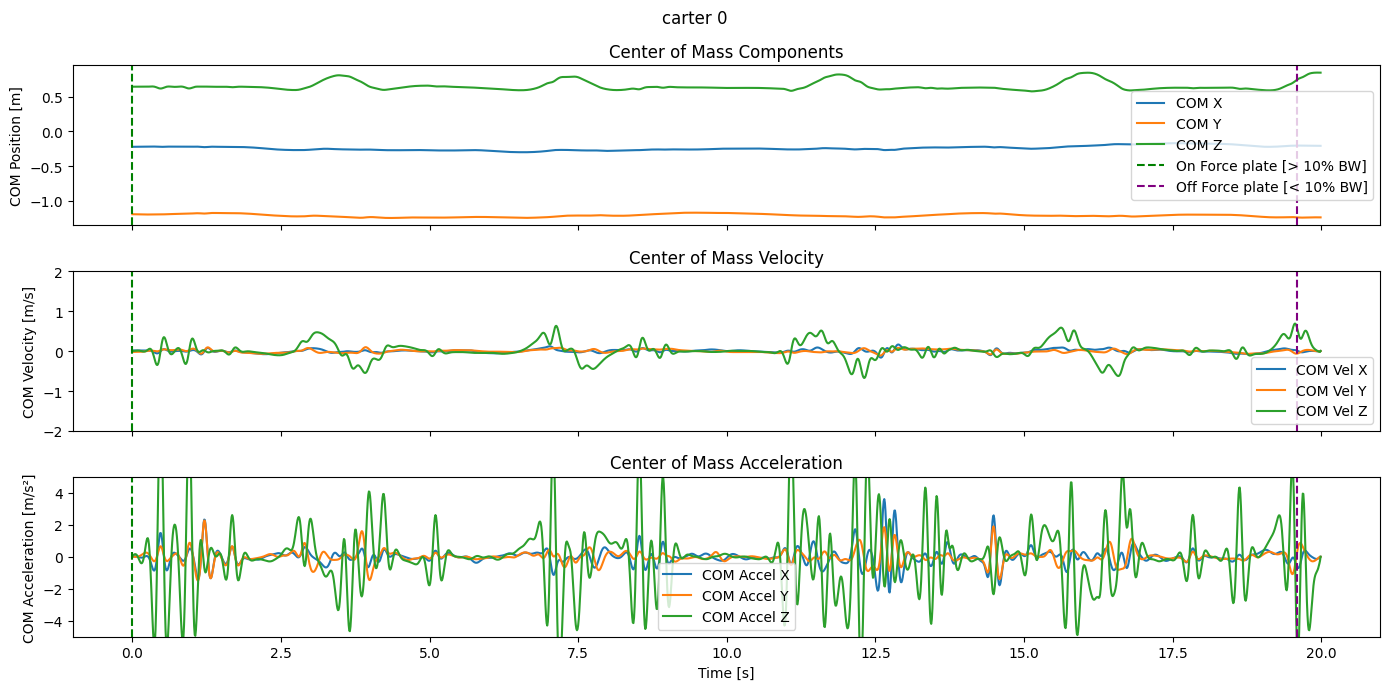

In [43]:
time = np.arange(com.shape[0]) * dt_markers  # dt_markers is the sampling frequency (Hz)

fig, axs = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
fig.suptitle(f"{subject_name}")

# COM position
axs[0].plot(time, com[:, 0], label="COM X")
axs[0].plot(time, com[:, 1], label="COM Y")
axs[0].plot(time, com[:, 2], label="COM Z")
axs[0].set_ylabel("COM Position [m]")
axs[0].set_title("Center of Mass Components")
axs[0].axvline(time[first_above], color="green", linestyle="--", label="On Force plate [> 10% BW]")
axs[0].axvline(time[last_below], color="purple", linestyle="--", label="Off Force plate [< 10% BW]")
axs[0].legend()

# COM velocity
axs[1].plot(time, com_vel[:, 0], label="COM Vel X")
axs[1].plot(time, com_vel[:, 1], label="COM Vel Y")
axs[1].plot(time, com_vel[:, 2], label="COM Vel Z")
axs[1].set_ylim(-2, 2)
axs[1].set_ylabel("COM Velocity [m/s]")
axs[1].set_title("Center of Mass Velocity")
axs[1].axvline(time[first_above], color="green", linestyle="--")
axs[1].axvline(time[last_below], color="purple", linestyle="--")
axs[1].legend()

# COM acceleration
axs[2].plot(time, com_accel[:, 0], label="COM Accel X")
axs[2].plot(time, com_accel[:, 1], label="COM Accel Y")
axs[2].plot(time, com_accel[:, 2], label="COM Accel Z")
axs[2].set_ylim(-5, 5)
axs[2].set_xlabel("Time [s]")
axs[2].set_ylabel("COM Acceleration [m/s²]")
axs[2].set_title("Center of Mass Acceleration")
axs[2].axvline(time[first_above], color="green", linestyle="--")
axs[2].axvline(time[last_below], color="purple", linestyle="--")
axs[2].legend()

plt.tight_layout()
plt.show()

### Compare Marker COM Acceleration and Force Plate Predicted Acceleration

In [44]:
num_marker_frames = marker_clouds.shape[0]
num_grf_frames = grf.shape[0]
# Downsample cop and grf to match the number of frames in marker_clouds
com_accel_FP = np.zeros((num_grf_frames, 3))
if num_grf_frames > num_marker_frames:
    # Calculate the downsampling ratio
    ratio = float(num_grf_frames) / float(num_marker_frames)
    # Create indices for downsampling
    indices = np.arange(num_marker_frames) * ratio
    indices = np.round(indices).astype(int)
    grf = grf[indices]

com_accel_FP = np.sum(grf, axis=1) / subject_mass - np.array([0, 0, 9.81])

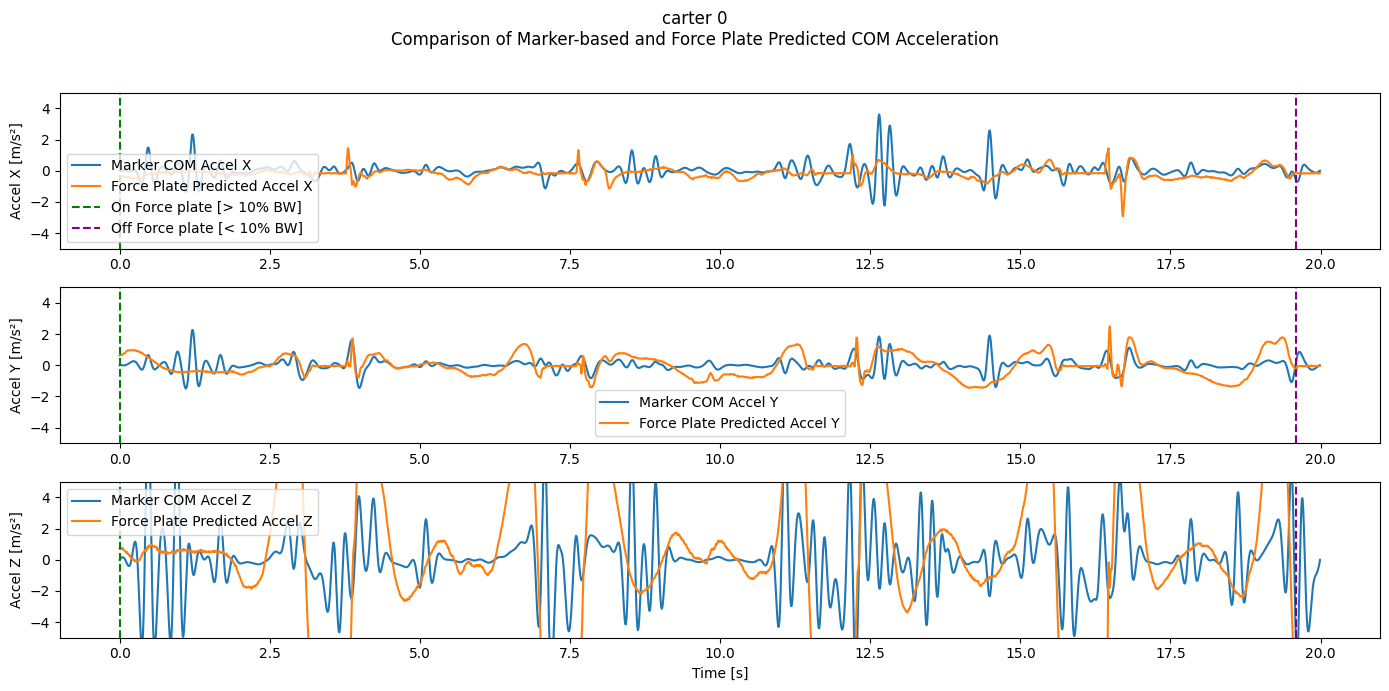

In [45]:
plt.figure(figsize=(14, 7))
labels = ["X", "Y", "Z"]
units = ["[m/s²]", "[m/s²]", "[m/s²]"]
for j in range(3):
    plt.subplot(3, 1, j + 1)
    plt.plot(time, com_accel[:, j], label="Marker COM Accel " + labels[j])
    plt.plot(time, com_accel_FP[:, j], label="Force Plate Predicted Accel " + labels[j])
    plt.axvline(time[first_above], color="green", linestyle="--", label="On Force plate [> 10% BW]" if j == 0 else None)
    plt.axvline(time[last_below], color="purple", linestyle="--", label="Off Force plate [< 10% BW]" if j == 0 else None)
    plt.ylabel(f"Accel {labels[j]} {units[j]}")
    plt.ylim(-5, 5)
    plt.legend()
plt.xlabel("Time [s]")
plt.suptitle(
    f"{subject_name}\nComparison of Marker-based and Force Plate Predicted COM Acceleration"
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()